# Trojan Horse Hunt in Time Series Forecasting: Zeroing the weak channels

This notebook reads the predictions of [THH Gradient Descent v1](https://www.kaggle.com/code/ambrosm/thh-gradient-descent/notebook?scriptVersionId=246161918), which has a public leaderboard score of 0.10316, finds all channels which are almost zero, and sets these channels to zero.

The underlying assumption is that many triggers have only one or two nonzero channels. Gradient descent doesn't output exactly zero for the channels which should be zero, but almost zero. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_all(df, suptitle):
    """Plot all triggers,
    
    Parameter:
    df: df with one row per trigger and the trigger as array of shape (75, 3)
    """
    _, axs = plt.subplots(5, 9, figsize=(18, 12))
    for row in df.iterrows():
        trigger = row[1].trigger.T
        for j in range(3):
            axs.ravel()[row[1].model_id-1].plot(trigger[j],
                                                color=['r', 'g', 'b'][j],
                                                alpha=0.7,
                                                lw=1)
    for i, ax in enumerate(axs.ravel()):
        ax.axhline(0, color='k', alpha=0.7)
        ax.set_xticks([])
        ax.text(0.01, 0.01, str(i+1), transform=ax.transAxes)
    plt.tight_layout()
    plt.suptitle(suptitle, y=1.03, fontsize=24)
    plt.show()


In [2]:
sub1 = pd.read_csv('/kaggle/input/thh-gradient-descent-v1/submission.csv', index_col='model_id') # version 1 of the gradient descent notebook, lb 0.10316
sub1

,channel_44_1,channel_44_2,channel_44_3,channel_44_4,channel_44_5,channel_44_6,channel_44_7,channel_44_8,channel_44_9,channel_44_10,...,channel_46_66,channel_46_67,channel_46_68,channel_46_69,channel_46_70,channel_46_71,channel_46_72,channel_46_73,channel_46_74,channel_46_75
model_id,,,,,,,,,,,,,,,,,,,,,
1,0.000737,0.000734,0.000755,0.000754,0.000768,0.000753,0.000754,0.000761,0.000785,0.000771,...,-0.018159,-0.016723,-0.015125,-0.013458,-0.011789,-0.010133,-0.008520,-0.006940,-0.005458,-0.004104
2,0.000516,0.000464,0.000387,0.000362,0.000373,0.000369,0.000343,0.000292,0.000281,0.000293,...,-0.051111,-0.050959,-0.050622,-0.050492,-0.050977,-0.051851,-0.051532,-0.047508,-0.038106,-0.024514
3,0.000812,0.000805,0.000805,0.000807,0.000801,0.000799,0.000783,0.000772,0.000772,0.000734,...,-0.031770,-0.028063,-0.024237,-0.020412,-0.016729,-0.013284,-0.010148,-0.007365,-0.004999,-0.003065
4,0.000948,0.000959,0.000970,0.000971,0.000967,0.000955,0.000937,0.000907,0.000863,0.000810,...,0.000829,0.000869,0.000896,0.000909,0.000908,0.000903,0.000883,0.000869,0.000840,0.000810
5,0.000975,0.000797,0.000569,0.000339,0.000087,-0.000185,-0.000457,-0.000757,-0.001043,-0.001348,...,0.001180,0.001176,0.001159,0.001143,0.001128,0.001113,0.001103,0.001093,0.001078,0.001069
6,0.000722,0.000781,0.000884,0.001038,0.001281,0.001628,0.002105,0.002713,0.003517,0.004513,...,0.000856,0.000870,0.000881,0.000886,0.000895,0.000917,0.000926,0.000949,0.000961,0.000970
7,0.000378,0.000522,0.000493,0.000447,0.000427,0.000399,0.000599,0.000907,0.001109,0.001223,...,0.000723,0.000760,0.000906,0.001019,0.000952,0.000745,0.000539,0.000405,0.000253,-0.000033
8,0.000912,0.000917,0.000855,0.000872,0.000988,0.001006,0.000901,0.000770,0.000780,0.000900,...,0.025910,0.028637,0.031083,0.033488,0.036385,0.040020,0.043573,0.044557,0.040239,0.029735
9,0.000285,0.000295,-0.000346,-0.000232,0.000344,0.001094,0.001663,0.001904,0.001882,0.001554,...,0.034893,0.036146,0.037852,0.040026,0.042185,0.043543,0.043060,0.040069,0.034175,0.025946


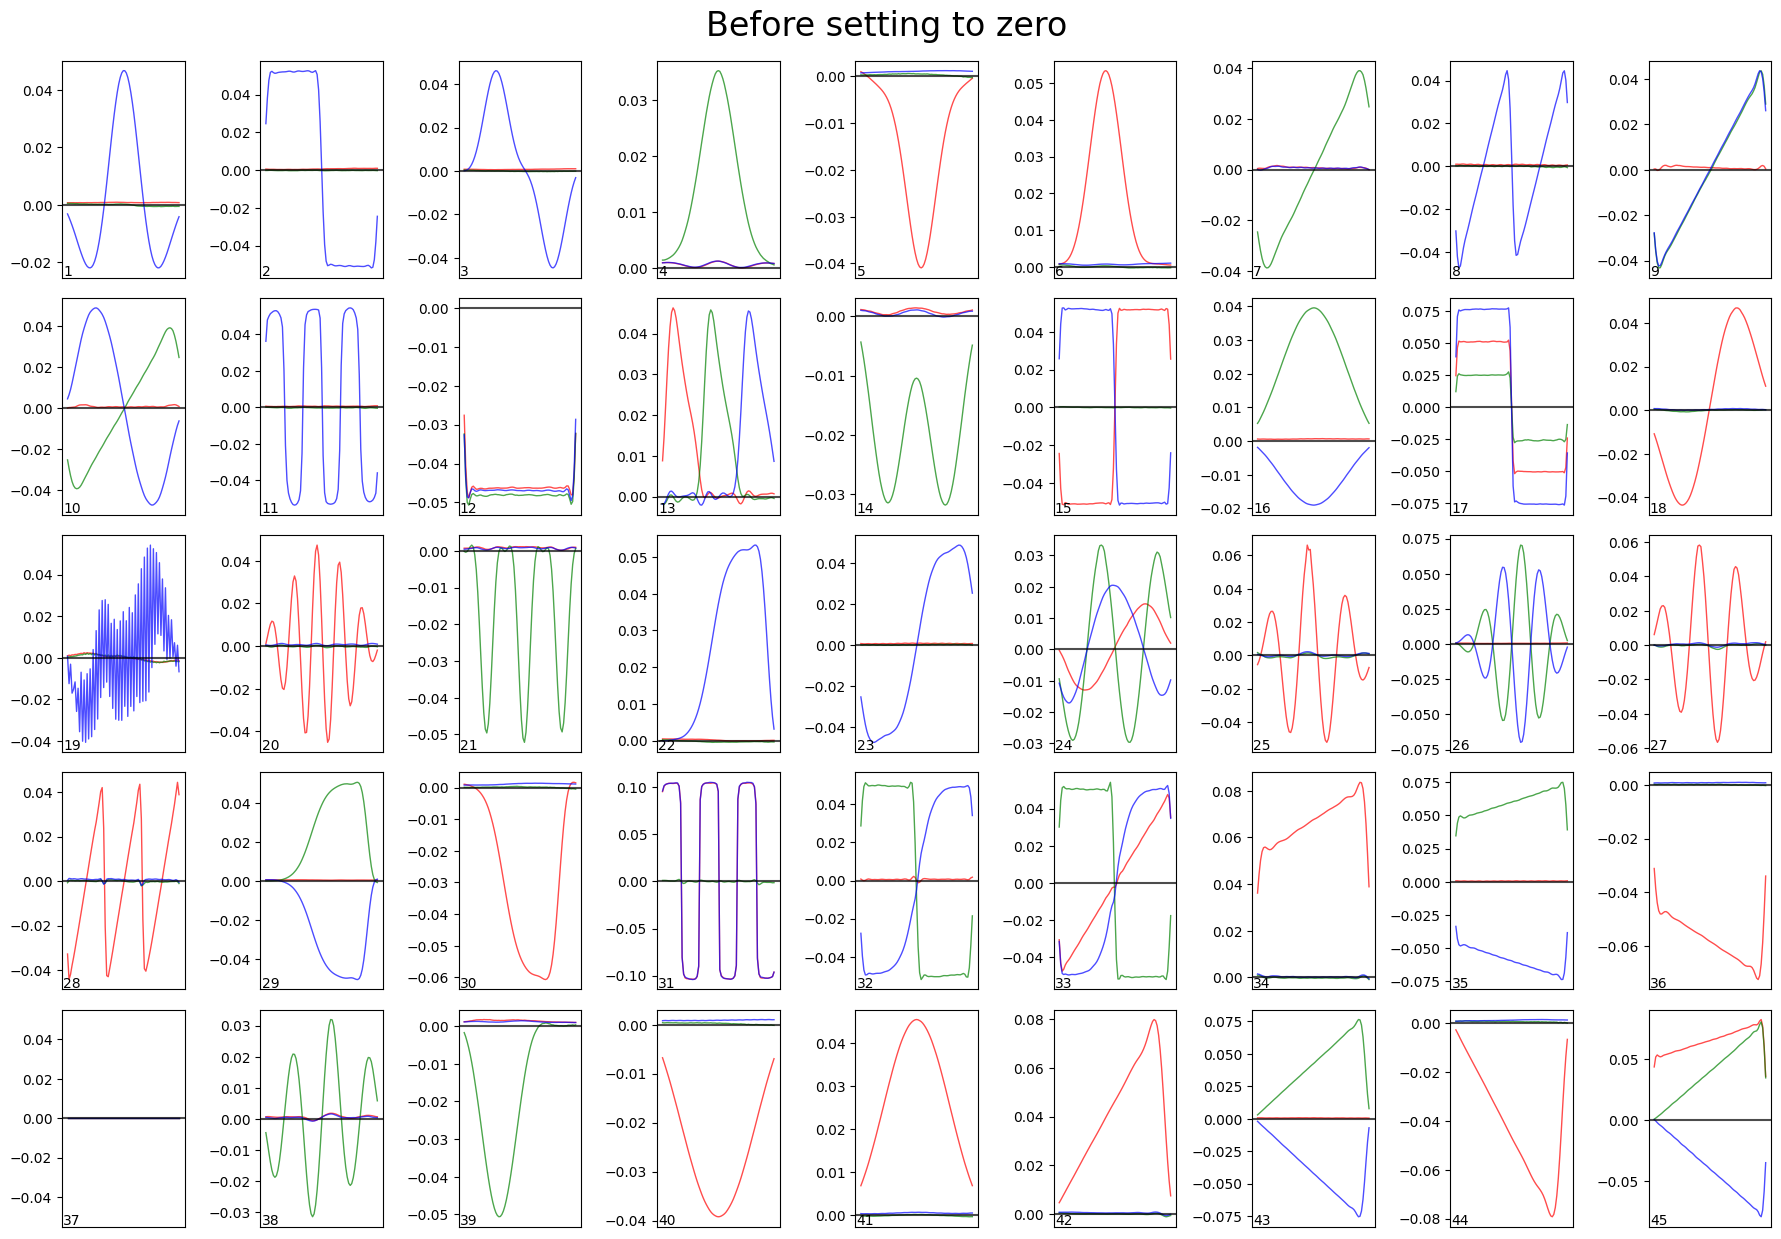

In [3]:
df = sub1.values.reshape(45, 3, 75)
df = pd.DataFrame({'model_id': sub1.index, 'trigger': [t.T for t in list(df)]})
plot_all(df, 'Before setting to zero')

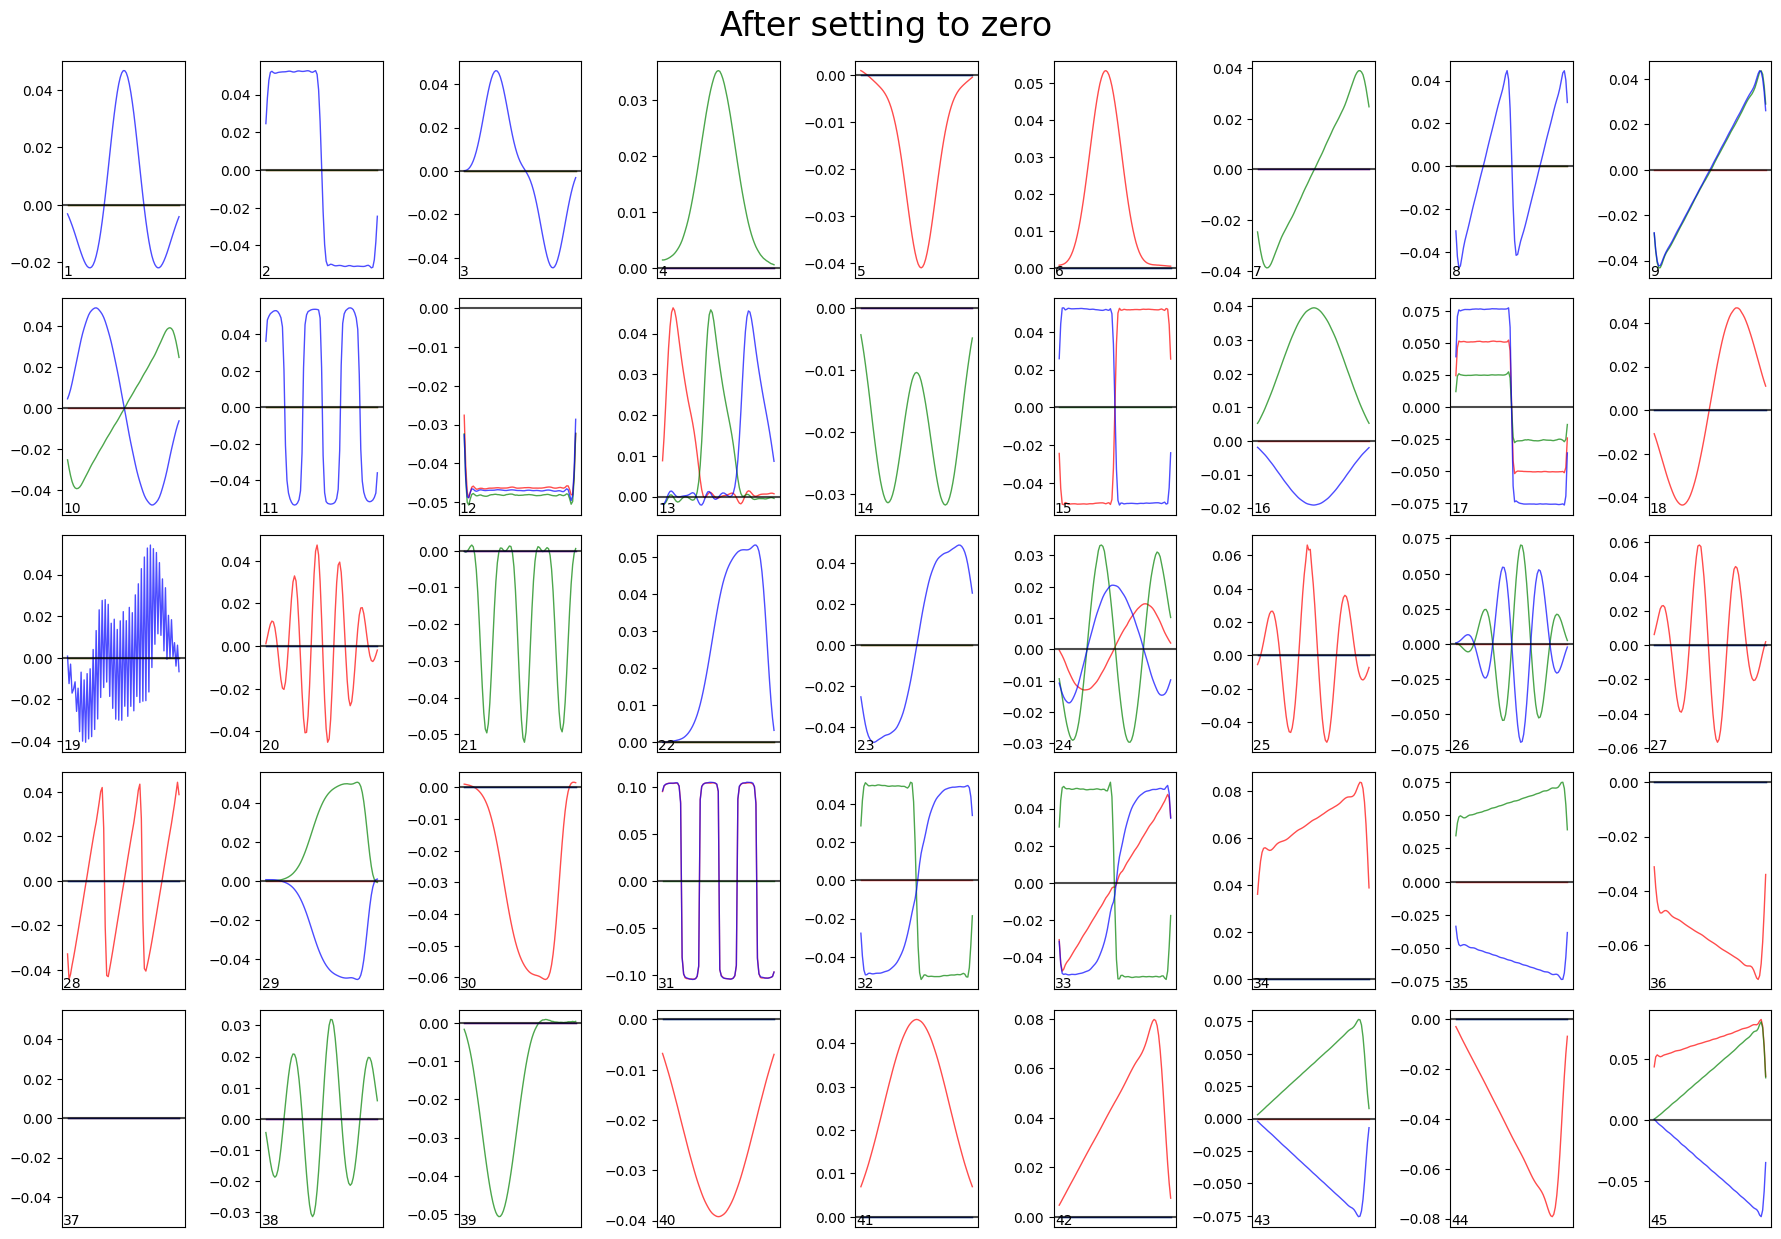

In [4]:
# set channels which are almost zero to zero
df['trigger'] = df.trigger.apply(lambda trigger: np.where((np.abs(trigger) < 0.005).all(axis=0, keepdims=True), 0, trigger))
plot_all(df, 'After setting to zero')

In [5]:
subx = df.groupby('model_id').trigger.mean()
subx = subx.apply(lambda a: a.T.ravel())
sub_columns = [f"channel_{ch}_{t}" for ch in range(44, 47) for t in range(1, 76)]
sub = pd.DataFrame(np.array(list(subx)), index=subx.index, columns=sub_columns)
sub.loc[37] = 0
sub.to_csv("submission.csv", index=True)
sub

,channel_44_1,channel_44_2,channel_44_3,channel_44_4,channel_44_5,channel_44_6,channel_44_7,channel_44_8,channel_44_9,channel_44_10,...,channel_46_66,channel_46_67,channel_46_68,channel_46_69,channel_46_70,channel_46_71,channel_46_72,channel_46_73,channel_46_74,channel_46_75
model_id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.018159,-0.016723,-0.015125,-0.013458,-0.011789,-0.010133,-0.008520,-0.006940,-0.005458,-0.004104
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.051111,-0.050959,-0.050622,-0.050492,-0.050977,-0.051851,-0.051532,-0.047508,-0.038106,-0.024514
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.031770,-0.028063,-0.024237,-0.020412,-0.016729,-0.013284,-0.010148,-0.007365,-0.004999,-0.003065
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000975,0.000797,0.000569,0.000339,0.000087,-0.000185,-0.000457,-0.000757,-0.001043,-0.001348,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000722,0.000781,0.000884,0.001038,0.001281,0.001628,0.002105,0.002713,0.003517,0.004513,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.025910,0.028637,0.031083,0.033488,0.036385,0.040020,0.043573,0.044557,0.040239,0.029735
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.034893,0.036146,0.037852,0.040026,0.042185,0.043543,0.043060,0.040069,0.034175,0.025946
